# ART Attacks

This notebook showcases ART attack families and subtypes without defenses.

The organizing rule is simple: each family is shown in its own scoring context.

- Evasion compares `benign_*` against `evasion_*`.
- Membership inference uses `membership_inference_*`.
- Attribute inference uses `inferred_<attribute>_*`.
- Additional families are catalogued separately so we do not mix incompatible metrics in one chart.

The implemented sections in this first pass are:

- sklearn logistic regression with several evasion subtypes
- torch `TinyNet` with several evasion subtypes
- membership inference on tabular data
- attribute inference on tabular data

In [1]:
from __future__ import annotations

import random
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.linear_model import LogisticRegression

from deckard.attack import AttackConfig, PytorchAttackConfig
from deckard.data import DataConfig, PytorchDataConfig
from deckard.model import ModelConfig, PytorchModelConfig
from deckard.score.data import DefaultPytorchDataScorerConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", palette="colorblind")

cwd = Path(".")
NOTEBOOK_ROOT = Path(".")
# Use notebooks/artifacts/art_attacks/ for all outputs
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "art_attacks"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Unique output file paths for each step
sklearn_data_file = ARTIFACT_DIR / "sklearn_data.pkl"
torch_data_file = ARTIFACT_DIR / "torch_data.pkl"
sklearn_model_file = ARTIFACT_DIR / "sklearn_model.pkl"
sklearn_svm_model_file = ARTIFACT_DIR / "svm.pkl"
sklearn_poisoned_model_file = ARTIFACT_DIR / "sklearn_poisoned_model.pkl"
sklearn_membership_attack_file = ARTIFACT_DIR / "sklearn_membership_attack.pkl"
sklearn_attribute_attack_file = ARTIFACT_DIR / "sklearn_attribute_attack.pkl"
torch_model_file = ARTIFACT_DIR / "torch_model.pkl"
sklearn_score_file = ARTIFACT_DIR / "sklearn_scores.csv"
torch_score_file = ARTIFACT_DIR / "torch_scores.csv"
sklearn_evasion_attack_file = ARTIFACT_DIR / "sklearn_evasion_attack.pkl"
sklearn_poison_attack_file = ARTIFACT_DIR / "sklearn_poisoning_attack.pkl"
torch_evasion_attack_file = ARTIFACT_DIR / "torch_evasion_attack.pkl"
torch_extraction_attack_file = ARTIFACT_DIR / "torch_extraction_attack.pkl"
plot_file = ARTIFACT_DIR / "plot.png"

TORCH_EXAMPLE_TARGET = "../../examples/pytorch/torch_example.py:ResNet18"
torch_example_file = NOTEBOOK_ROOT / "../../examples/pytorch/torch_example.py"
if not torch_example_file.exists():
    raise FileNotFoundError(f"Missing torch example module file: {torch_example_file}")

print(f"Artifacts will be written under: {ARTIFACT_DIR}")
print(f"Using torch model target: {TORCH_EXAMPLE_TARGET}")

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifacts will be written under: build/art_attacks
Using torch model target: ../../examples/pytorch/torch_example.py:ResNet18


In [2]:
attack_catalog = pd.DataFrame(
    [
        {
            "attack_family": "evasion",
            "attack_subtype": "FastGradientMethod",
            "native_score_context": "benign_* vs evasion_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "evasion",
            "attack_subtype": "HopSkipJump",
            "native_score_context": "benign_* vs evasion_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "evasion",
            "attack_subtype": "BoundaryAttack",
            "native_score_context": "benign_* vs evasion_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "membership_inference",
            "attack_subtype": "MembershipInferenceBlackBox",
            "native_score_context": "membership_inference_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "attribute_inference",
            "attack_subtype": "AttributeInferenceBlackBox",
            "native_score_context": "inferred_<attribute>_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "poisoning",
            "attack_subtype": "PoisoningAttackSVM",
            "native_score_context": "benign_* vs poisoned_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "extraction",
            "attack_subtype": "CopycatCNN",
            "native_score_context": "benign_* vs extracted_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "model_inversion",
            "attack_subtype": "MIFace",
            "native_score_context": "model_inversion_*",
            "implementation_status": "implemented",
        },
        {
            "attack_family": "reconstruction",
            "attack_subtype": "DatabaseReconstruction",
            "native_score_context": "database_reconstruction_*",
            "implementation_status": "implemented",
        },
    ]
)

display(attack_catalog)

,attack_family,attack_subtype,native_score_context,implementation_status
0,evasion,FastGradientMethod,benign_* vs evasion_*,implemented
1,evasion,HopSkipJump,benign_* vs evasion_*,implemented
2,evasion,BoundaryAttack,benign_* vs evasion_*,implemented
3,membership_inference,MembershipInferenceBlackBox,membership_inference_*,implemented
4,attribute_inference,AttributeInferenceBlackBox,inferred_<attribute>_*,implemented
5,poisoning,PoisoningAttackSVM,benign_* vs poisoned_*,implemented
6,extraction,CopycatCNN,benign_* vs extracted_*,implemented
7,model_inversion,MIFace,model_inversion_*,implemented
8,reconstruction,DatabaseReconstruction,database_reconstruction_*,implemented


## Declarations and Helper Functions

In [3]:
def as_numeric(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    return value


def score_rows(scores, prefix, model_name, attack_family, attack_subtype):
    rows = []
    for key, value in scores.items():
        if key.startswith(prefix) and isinstance(
            value, (int, float, np.integer, np.floating)
        ):
            rows.append(
                {
                    "model_name": model_name,
                    "attack_family": attack_family,
                    "attack_subtype": attack_subtype,
                    "metric_name": key,
                    "metric_value": float(value),
                }
            )
    return rows


def timing_payload(scores):
    keys = [
        "attack_size",
        "attack_generation_time",
        "attack_prediction_time",
        "attack_score_time",
    ]
    return {key: as_numeric(scores.get(key)) for key in keys}


def plot_grouped_accuracy(
    df, title, clean_column="clean_test_accuracy", attack_column="attack_accuracy"
):
    plot_df = df.melt(
        id_vars=["model_name", "attack_subtype"],
        value_vars=[clean_column, attack_column],
        var_name="metric_label",
        value_name="metric_value",
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x="attack_subtype", y="metric_value", hue="metric_label")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel("Attack subtype")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def plot_metric_context(metric_df, title):
    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=metric_df, x="metric_name", y="metric_value", hue="attack_subtype"
    )
    plt.title(title)
    plt.xlabel("Metric")
    plt.ylabel("Value")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


def make_sensitive_tabular_data(n_train=180, n_test=90, seed=SEED):
    rng = np.random.default_rng(seed)

    age_train = rng.integers(18, 70, size=n_train)
    age_test = rng.integers(18, 70, size=n_test)
    sensitive_train = (age_train >= 45).astype(int)
    sensitive_test = (age_test >= 45).astype(int)

    X_train = pd.DataFrame(
        {
            "feat0": rng.normal(size=n_train),
            "feat1": rng.normal(size=n_train),
            "feat2": rng.normal(size=n_train),
            "age": age_train,
            "sensitive": sensitive_train,
        }
    )
    X_test = pd.DataFrame(
        {
            "feat0": rng.normal(size=n_test),
            "feat1": rng.normal(size=n_test),
            "feat2": rng.normal(size=n_test),
            "age": age_test,
            "sensitive": sensitive_test,
        }
    )

    y_train = pd.Series(
        (
            1.1 * X_train["feat0"]
            - 0.7 * X_train["feat1"]
            + 0.03 * X_train["age"]
            + 0.4 * X_train["sensitive"]
            > 0.9
        ).astype(int),
        name="target",
    )
    y_test = pd.Series(
        (
            1.1 * X_test["feat0"]
            - 0.7 * X_test["feat1"]
            + 0.03 * X_test["age"]
            + 0.4 * X_test["sensitive"]
            > 0.9
        ).astype(int),
        name="target",
    )

    data = SimpleNamespace(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        classifier=True,
        _sensitive_train=pd.Series(sensitive_train, name="sensitive"),
        _sensitive_test=pd.Series(sensitive_test, name="sensitive"),
    )
    return data


class TinyNet(nn.Module):
    def __init__(self, in_features=8, hidden_features=16, out_features=2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, out_features),
        )

    def forward(self, x):
        return self.layers(x)


def build_torch_tensor_data(seed=SEED):
    torch.manual_seed(seed)
    X = torch.rand(72, 8)
    weights = torch.tensor(
        [0.8, -0.4, 0.6, 0.2, -0.3, 0.5, -0.1, 0.4], dtype=torch.float32
    )
    logits = X @ weights
    y = (logits > logits.median()).long()
    data = PytorchDataConfig(
        dataset_name="torch.utils.data.TensorDataset",
        train_size=48,
        test_size=24,
        classifier=True,
        random_state=seed,
        scorer=DefaultPytorchDataScorerConfig(classifier=True),
        data_params={"_args_": [X, y]},
    )
    data()
    return data


def build_torch_image_data(seed=SEED, n_samples=20, height=32, width=32):
    torch.manual_seed(seed)
    images = torch.rand(n_samples, 3, height, width)
    labels = (images.mean(dim=(1, 2, 3)) > 0.5).long()
    data = PytorchDataConfig(
        dataset_name="torch.utils.data.TensorDataset",
        train_size=14,
        test_size=6,
        classifier=True,
        random_state=seed,
        scorer=DefaultPytorchDataScorerConfig(classifier=True),
        data_params={"_args_": [images, labels]},
    )
    data()
    return data


sklearn_data = DataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 220,
        "n_features": 10,
        "n_informative": 6,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "n_classes": 2,
        "class_sep": 1.4,
        "random_state": SEED,
    },
    train_size=160,
    test_size=60,
    random_state=SEED,
    stratify=True,
    classifier=True,
    # data_file=sklearn_evasion_data_file,  # PATCH: moved to call below
)

In [4]:
sklearn_data(data_file=sklearn_data_file)

sklearn_model = ModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 300},
    # model_file=sklearn_model_file,  # Moved to call below
)
log_scores = sklearn_model(sklearn_data, model_file=sklearn_model_file)

sklearn_svm = ModelConfig(
    model_type="sklearn.svm.SVC",
    classifier=True,
    model_params={"max_iter": 300, "probability": True},
    # model_file=sklearn_model_
    # file,  # Moved to call below
)
svm_scores = sklearn_svm(sklearn_data, model_file=sklearn_svm_model_file)

print("LogisticRegression:")
print(log_scores)
print("SVM:")
print(svm_scores)

LogisticRegression:
{'test': {'accuracy': 0.98, 'precision': 0.98, 'recall': 0.98, 'f1': 0.98, 'roc_auc': 0.98, 'log_loss': 0.13}, 'accuracy': 0.98, 'precision': 0.98, 'recall': 0.98, 'f1': 0.98, 'roc_auc': 0.98, 'log_loss': 0.13, 'training_time': 0.006846310000000244, 'training_n': 160, 'prediction_time': 0.0006784299999997856, 'prediction_n': 60, 'prediction_score_time': 0.0439205540000005}
SVM:
{'test': {'accuracy': 0.98, 'precision': 0.98, 'recall': 0.98, 'f1': 0.98, 'roc_auc': 0.98, 'log_loss': 0.12}, 'accuracy': 0.98, 'precision': 0.98, 'recall': 0.98, 'f1': 0.98, 'roc_auc': 0.98, 'log_loss': 0.12, 'training_time': 0.015670615999999526, 'training_n': 160, 'prediction_time': 0.003914185000000181, 'prediction_n': 60, 'prediction_score_time': 0.04040876300000029}


In [5]:
sklearn_data_file

PosixPath('build/art_attacks/sklearn_data.pkl')

## Evasion: sklearn logistic regression

Evasion is the one family where a clean-versus-attacked side-by-side bar chart is directly meaningful because the native score context already contains both benign and adversarial predictions.

{'benign_accuracy': 1.0, 'benign_precision': 1.0, 'benign_recall': 1.0, 'benign_f1': 1.0, 'benign_success': 0.0, 'benign_attack_size': 24, 'benign_attack_score_time': 0.005115350000011176, 'evasion_accuracy': 1.0, 'evasion_precision': 1.0, 'evasion_recall': 1.0, 'evasion_f1-score': 1.0, 'evasion_success': 0.0, 'attack_size': 24, 'attack_score_time': 0.004465428999992582, 'attack_generation_time': 0.0012312709999946492, 'attack_prediction_time': 0.0001326500000118358}
{'benign_accuracy': 1.0, 'benign_precision': 1.0, 'benign_recall': 1.0, 'benign_f1': 1.0, 'benign_success': 0.0, 'benign_attack_size': 12, 'benign_attack_score_time': 0.004852382999985139, 'evasion_accuracy': 0.0, 'evasion_precision': 0.0, 'evasion_recall': 0.0, 'evasion_f1-score': 0.0, 'evasion_success': 1.0, 'attack_size': 12, 'attack_score_time': 0.004415412999975388, 'attack_generation_time': 0.0646522579999953, 'attack_prediction_time': 9.69570000108888e-05}
{'benign_accuracy': 1.0, 'benign_precision': 1.0, 'benign_re

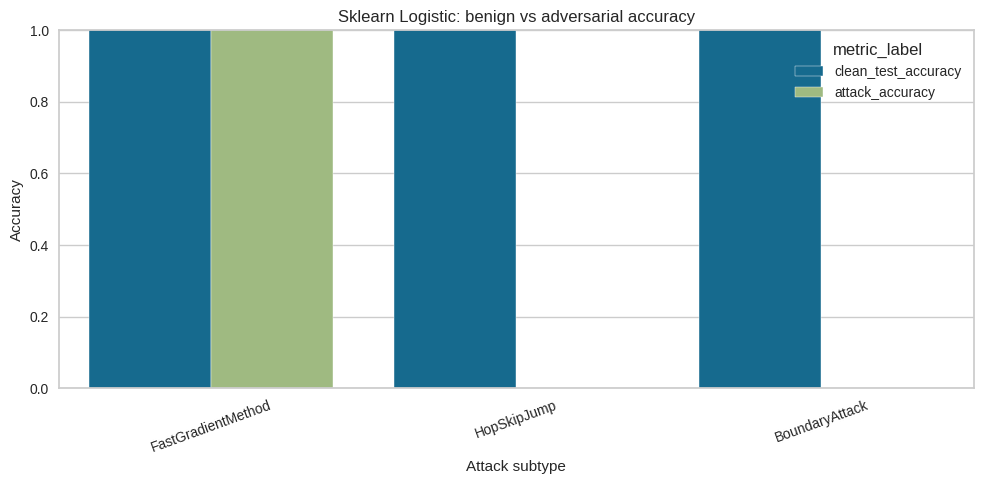

In [6]:
# Evasion attack specifications and config (must be defined before use)
sklearn_evasion_specs = [
    {
        "attack_subtype": "FastGradientMethod",
        "attack_type": "art.attacks.evasion.FastGradientMethod",
        "attack_params": {
            "eps": 0.15,
            "eps_step": 0.05,
            "norm": "inf",
            "targeted": False,
            "minimal": False,
        },
        "attack_size": 24,
        "alias": "fgm",
    },
    {
        "attack_subtype": "HopSkipJump",
        "attack_type": "art.attacks.evasion.HopSkipJump",
        "attack_params": {
            "max_iter": 3,
            "init_eval": 4,
            "max_eval": 16,
            "init_size": 12,
            "norm": 2,
            "targeted": False,
            "verbose": False,
        },
        "attack_size": 12,
        "alias": "hsj",
    },
    {
        "attack_subtype": "BoundaryAttack",
        "attack_type": "art.attacks.evasion.BoundaryAttack",
        "attack_params": {
            "batch_size": 6,
            "targeted": False,
            "delta": 0.01,
            "epsilon": 0.01,
            "max_iter": 2,
            "num_trial": 5,
            "sample_size": 6,
            "init_size": 12,
            "min_epsilon": 0.0,
            "verbose": False,
        },
        "attack_size": 12,
        "alias": "boundary",
    },
]


sklearn_evasion_rows = []
for spec in sklearn_evasion_specs:
    attack = AttackConfig(
        attack_type=spec["attack_type"],
        attack_params=spec["attack_params"],
        attack_size=spec["attack_size"],
    )
    sklearn_evasion_attack_subset_file = (
        ARTIFACT_DIR / (str(spec["alias"]) + str("_evasion_attack_file.pkl"))
    ).as_posix()
    scores = attack(
        data=sklearn_data,
        model=sklearn_model,
        attack_file=sklearn_evasion_attack_subset_file,
    )
    print(scores)
    sklearn_evasion_rows.append(
        {
            "model_name": "sklearn_logistic",
            "attack_family": "evasion",
            "attack_subtype": spec["attack_subtype"],
            "clean_test_accuracy": float(scores["benign_accuracy"]),
            "attack_accuracy": float(scores["evasion_accuracy"]),
            **timing_payload(scores),
        }
    )

sklearn_evasion_df = pd.DataFrame(sklearn_evasion_rows)
plot_grouped_accuracy(
    sklearn_evasion_df, "Sklearn Logistic: benign vs adversarial accuracy"
)

sklearn_evasion_df.to_csv(
    sklearn_score_file, index=False
)  # Output: sklearn_scores.csv

## Poisoning: sklearn SVC

This section uses ART's `PoisoningAttackSVM` with a sklearn `SVC` victim. The comparison stays inside the poisoning score context and reports `benign_*` against `poisoned_*`.

sklearn_poison_scores keys: ['benign_accuracy', 'benign_precision', 'benign_recall', 'benign_f1', 'benign_success', 'benign_attack_size', 'benign_attack_score_time', 'poisoned_accuracy', 'poisoned_precision', 'poisoned_recall', 'poisoned_f1', 'poisoned_success', 'poisoned_attack_size', 'poisoned_attack_score_time', 'poisoning_attack_points', 'poison_mode', 'attack_size', 'attack_generation_time', 'attack_prediction_time', 'attack_score_time']


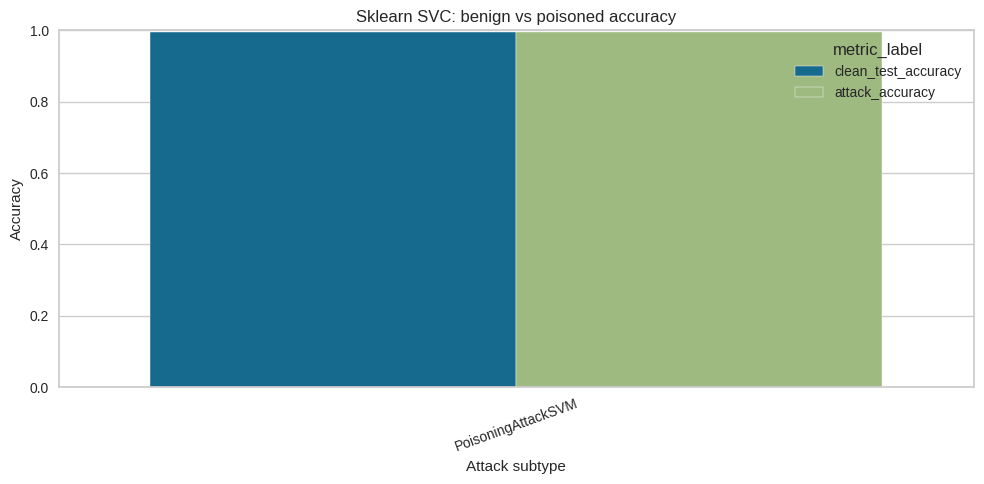

In [7]:
sklearn_poison_attack = AttackConfig(
    attack_type="art.attacks.poisoning.PoisoningAttackSVM",
    attack_params={"step": 0.05, "eps": 0.2, "max_iter": 2, "verbose": False},
    attack_size=6,
)
sklearn_poison_scores = sklearn_poison_attack(data=sklearn_data, model=sklearn_svm)

print("sklearn_poison_scores keys:", list(sklearn_poison_scores.keys()))

sklearn_poison_df = pd.DataFrame(
    [
        {
            "model_name": "sklearn_svc",
            "attack_family": "poisoning",
            "attack_subtype": "PoisoningAttackSVM",
            "clean_accuracy": float(
                sklearn_poison_scores.get("benign_accuracy", float("nan"))
            ),
            "poisoned_accuracy": float(
                sklearn_poison_scores.get("poisoned_accuracy", float("nan"))
            ),
            **timing_payload(sklearn_poison_scores),
        }
    ]
)

plot_grouped_accuracy(
    sklearn_poison_df.rename(
        columns={
            "clean_accuracy": "clean_test_accuracy",
            "poisoned_accuracy": "attack_accuracy",
        }
    ),
    "Sklearn SVC: benign vs poisoned accuracy",
)

sklearn_poison_df.to_csv(sklearn_score_file, index=False)  # Output: sklearn_scores.csv

## Membership Inference

This section uses the membership-inference score namespace directly. The chart below compares membership-specific metrics only, so the bars stay within one scoring context.

membership_scores keys: ['membership_inference_accuracy', 'membership_inference_precision', 'membership_inference_recall', 'membership_inference_f1', 'attack_size', 'attack_score_time', 'attack_generation_time', 'attack_prediction_time']


,model_name,attack_family,attack_subtype,metric_name,metric_value
0,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_accuracy,0.33
1,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_precision,0.11
2,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_recall,0.33
3,sklearn_logistic,membership_inference,MembershipInferenceBlackBox,membership_inference_f1,0.17


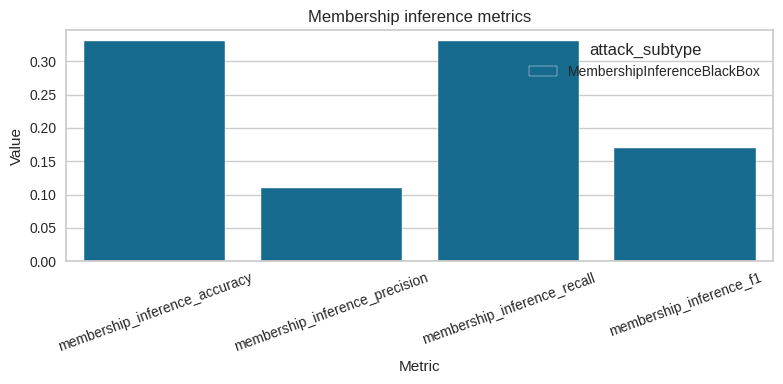

In [8]:
membership_data = make_sensitive_tabular_data()
membership_model = LogisticRegression(max_iter=300)
membership_model.fit(membership_data.X_train.values, membership_data.y_train.values)

membership_attack = AttackConfig(
    attack_type="art.attacks.inference.membership_inference.MembershipInferenceBlackBox",
    attack_params={},
    attack_size=60,
    # attack_file=attack_file,  # PATCH: moved to call below
)
membership_scores = membership_attack(
    data=membership_data,
    model=membership_model,
    attack_file=sklearn_membership_attack_file,
)

print("membership_scores keys:", list(membership_scores.keys()))

# Try with the intended prefix
rows = score_rows(
    membership_scores,
    prefix="membership_inference_",
    model_name="sklearn_logistic",
    attack_family="membership_inference",
    attack_subtype="MembershipInferenceBlackBox",
)
# If no rows, fallback to all numeric keys
if not rows:
    for key, value in membership_scores.items():
        if isinstance(value, (int, float, np.integer, np.floating)):
            rows.append(
                {
                    "model_name": "sklearn_logistic",
                    "attack_family": "membership_inference",
                    "attack_subtype": "MembershipInferenceBlackBox",
                    "metric_name": key,
                    "metric_value": float(value),
                }
            )

membership_metric_df = pd.DataFrame(rows)
display(membership_metric_df)
if not membership_metric_df.empty:
    plot_metric_context(membership_metric_df, "Membership inference metrics")

# PATCH: Define score_file for this section
score_file = ARTIFACT_DIR / "membership_scores.csv"
membership_metric_df.to_csv(score_file, index=False)  # Output: scores.csv

## Attribute Inference

Attribute inference can score either classification or regression-style targets. Here the targeted attribute is continuous (`age`), so the notebook keeps the output in a regression-style table instead of forcing it into an accuracy chart.

In [9]:
attribute_data = make_sensitive_tabular_data(seed=SEED + 1)
attribute_model = LogisticRegression(max_iter=300)
attribute_model.fit(attribute_data.X_train.values, attribute_data.y_train.values)

attribute_attack = AttackConfig(
    attack_type="art.attacks.inference.attribute_inference.AttributeInferenceBlackBox",
    targeted_attribute=["age"],
    attack_params={
        "attack_model_type": "nn",
        "is_continuous": True,
        "scale_range": (18, 70),
        "nn_model_epochs": 10,
    },
    attack_size=70,
    # attack_file=attack_file,  # PATCH: moved to call below
)
attribute_scores = attribute_attack(
    data=attribute_data,
    model=attribute_model,
    attack_file=sklearn_attribute_attack_file,
)

# Try with the intended prefix
rows = score_rows(
    attribute_scores,
    prefix="inferred_age_",
    model_name="sklearn_logistic",
    attack_family="attribute_inference",
    attack_subtype="AttributeInferenceBlackBox",
)
# If no rows, fallback to all numeric keys
if not rows:
    for key, value in attribute_scores.items():
        if isinstance(value, (int, float, np.integer, np.floating)):
            rows.append(
                {
                    "model_name": "sklearn_logistic",
                    "attack_family": "attribute_inference",
                    "attack_subtype": "AttributeInferenceBlackBox",
                    "metric_name": key,
                    "metric_value": float(value),
                }
            )

attribute_metric_df = pd.DataFrame(rows)
if "metric_name" in attribute_metric_df.columns:
    attribute_metric_df = attribute_metric_df.sort_values("metric_name")
attribute_metric_df.to_csv(score_file, index=False)  # Output: scores.csv

## Evasion: torch TinyNet

The torch section reuses the repo's TensorDataset path and a tiny neural classifier. It stays inside the same evasion score context as the sklearn section, so the charts are directly interpretable within the family.

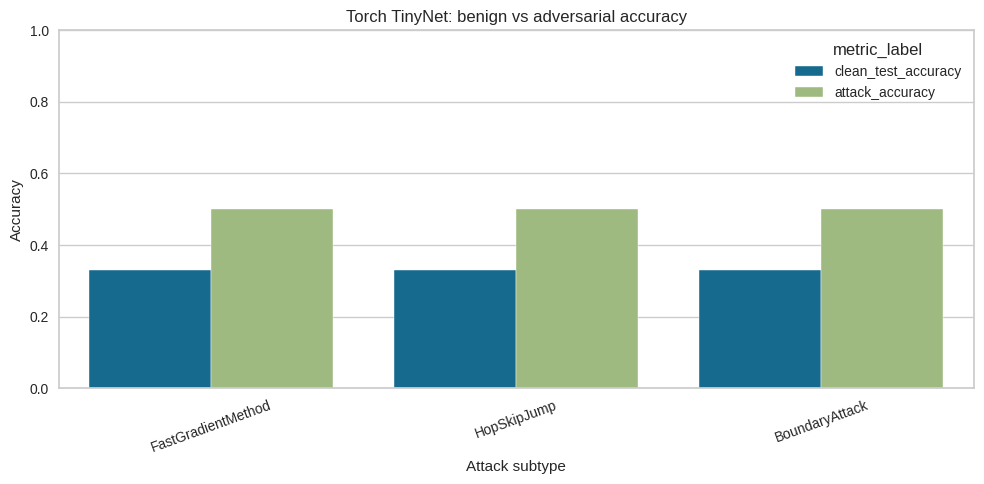

<Figure size 800x550 with 0 Axes>

In [10]:
torch_evasion_specs = [
    {
        "attack_subtype": "FastGradientMethod",
        "attack_type": "art.attacks.evasion.FastGradientMethod",
        "attack_params": {
            "eps": 0.12,
            "eps_step": 0.04,
            "norm": "inf",
            "targeted": False,
            "minimal": False,
        },
        "attack_size": 12,
    },
    {
        "attack_subtype": "HopSkipJump",
        "attack_type": "art.attacks.evasion.HopSkipJump",
        "attack_params": {
            "max_iter": 2,
            "init_eval": 4,
            "max_eval": 12,
            "init_size": 8,
            "norm": 2,
            "targeted": False,
            "verbose": False,
        },
        "attack_size": 8,
    },
    {
        "attack_subtype": "BoundaryAttack",
        "attack_type": "art.attacks.evasion.BoundaryAttack",
        "attack_params": {
            "batch_size": 4,
            "targeted": False,
            "delta": 0.01,
            "epsilon": 0.01,
            "max_iter": 2,
            "num_trial": 4,
            "sample_size": 4,
            "init_size": 8,
            "min_epsilon": 0.0,
            "verbose": False,
        },
        "attack_size": 8,
    },
]

torch_evasion_data = build_torch_tensor_data()
torch_evasion_model = PytorchModelConfig(
    model_type="deckard.frameworks.pytorch.declarations.TinyNet",
    model_params={"input_dim": 8, "hidden_dim": 16, "output_dim": 2},
    classifier=True,
    fit_params={"nb_epochs": 3, "batch_size": 16},
    criterion="CrossEntropyLoss",
    optimizer={"name": "SGD", "lr": 0.05},
    # model_file=torch_model_file,  # PATCH: moved to call below
)
torch_evasion_model(torch_evasion_data, model_file=torch_model_file)

torch_evasion_rows = []
for spec in torch_evasion_specs:
    attack = PytorchAttackConfig(
        attack_type=spec["attack_type"],
        attack_params=spec["attack_params"],
        attack_size=spec["attack_size"],
        # attack_file=attack_file,  # PATCH: moved to call below
    )
    scores = attack(
        data=torch_evasion_data,
        model=torch_evasion_model,
        attack_file=torch_evasion_attack_file,
    )
    torch_evasion_rows.append(
        {
            "model_name": "torch_tinynet",
            "attack_family": "evasion",
            "attack_subtype": spec["attack_subtype"],
            "clean_test_accuracy": float(scores["benign_accuracy"]),
            "attack_accuracy": float(scores["evasion_accuracy"]),
            **timing_payload(scores),
        }
    )

torch_evasion_df = pd.DataFrame(torch_evasion_rows)
plot_grouped_accuracy(
    torch_evasion_df, "Torch TinyNet: benign vs adversarial accuracy"
)

torch_evasion_df.to_csv(torch_score_file, index=False)  # Output: torch_scores.csv
plt.savefig(plot_file)  # Output: attack_plot.png

In [11]:
torch_extraction_data = build_torch_image_data(seed=SEED + 20)
torch_extraction_model_file = (
    ARTIFACT_DIR / "torch_extraction_model.pkl"
)  # Unique file for extraction

torch_extraction_model = PytorchModelConfig(
    model_type=TORCH_EXAMPLE_TARGET,
    model_params={"num_channels": 3, "num_classes": 2},
    classifier=True,
    fit_params={"nb_epochs": 1, "batch_size": 2},
    criterion="CrossEntropyLoss",
    optimizer={"name": "SGD", "lr": 0.001},
    # model_file=torch_extraction_model_file,  # PATCH: moved to call below
)
torch_extraction_model(torch_extraction_data, model_file=torch_extraction_model_file)

torch_extraction_attack = AttackConfig(
    attack_type="art.attacks.extraction.CopycatCNN",
    attack_params={
        "batch_size_fit": 2,
        "batch_size_query": 2,
        "nb_epochs": 1,
        "nb_stolen": 4,
    },
    attack_size=4,
    # attack_file=attack_file,  # PATCH: moved to call below
)
torch_extraction_scores = torch_extraction_attack(
    data=torch_extraction_data,
    model=torch_extraction_model,
    attack_file=torch_extraction_attack_file,
)

# Save results
torch_extraction_df = pd.DataFrame(
    score_rows(
        torch_extraction_scores,
        prefix="extracted_",
        model_name="torch_resnet18",
        attack_family="extraction",
        attack_subtype="CopycatCNN",
    )
)
torch_extraction_df.to_csv(torch_score_file, index=False)  # Output: torch_scores.csv

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/runner/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  2%|▏         | 896k/44.7M [00:00<00:05, 9.00MB/s]

 16%|█▌        | 7.12M/44.7M [00:00<00:00, 41.3MB/s]

 92%|█████████▏| 40.9M/44.7M [00:00<00:00, 182MB/s] 

100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]

In [12]:
torch_extraction_data = build_torch_image_data(seed=SEED + 20)
torch_extraction_model_file = (
    ARTIFACT_DIR / "torch_extraction_model.pkl"
)  # Unique file for extraction

torch_extraction_model = PytorchModelConfig(
    model_type=TORCH_EXAMPLE_TARGET,
    model_params={"num_channels": 3, "num_classes": 2},
    classifier=True,
    fit_params={"nb_epochs": 1, "batch_size": 2},
    criterion="CrossEntropyLoss",
    optimizer={"name": "SGD", "lr": 0.001},
    # model_file=torch_extraction_model_file,  # PATCH: moved to call below
)
torch_extraction_model(torch_extraction_data, model_file=torch_extraction_model_file)

torch_extraction_attack = AttackConfig(
    attack_type="art.attacks.extraction.CopycatCNN",
    attack_params={
        "batch_size_fit": 2,
        "batch_size_query": 2,
        "nb_epochs": 1,
        "nb_stolen": 4,
    },
    attack_size=4,
    # attack_file=attack_file,  # PATCH: moved to call below
)
torch_extraction_scores = torch_extraction_attack(
    data=torch_extraction_data,
    model=torch_extraction_model,
    attack_file=torch_extraction_attack_file,
)

# Save results
torch_extraction_df = pd.DataFrame(
    score_rows(
        torch_extraction_scores,
        prefix="extracted_",
        model_name="torch_resnet18",
        attack_family="extraction",
        attack_subtype="CopycatCNN",
    )
)
torch_extraction_df.to_csv(torch_score_file, index=False)  # Output: torch_scores.csv

## Optional Dependencies

This notebook runs ART attack workflows, including torch-backed examples.

Recommended extras:

- `docs`
- `torch`

Install from repository root:

```bash
pip install -e '.[docs,torch]'
```

In [13]:
# Optional dependency installation (run only if your environment is missing packages)
# !pip install -e '../../.[docs,torch]'